In [29]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import random


In [31]:
np.random.seed(34)
tf.random.set_seed(34)
random.seed(34)


In [33]:
data = pd.read_csv('data_stocks.csv')
data = data.drop(['DATE'], axis=1)

In [35]:
data['SP500'] = data['SP500'].shift(-1)
data = data.dropna(axis=0)

In [37]:
data_a = np.array(data)

In [39]:
n = data_a.shape[0]
train_end = int(np.floor(0.8 * n)) - 12
test_start = train_end
data_train = data_a[:train_end, :]
data_test = data_a[test_start:, :]

In [41]:
scaler = MinMaxScaler()
scaler.fit(data_train)
data_train_norm = scaler.transform(data_train)
data_test_norm = scaler.transform(data_test)

In [43]:
X_train = data_train_norm[:, 1:]
y_train = data_train_norm[:, 0]
X_test = data_test_norm[:, 1:]
y_test = data_test_norm[:, 0]


In [45]:

model = Sequential([
    Dense(34, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(17, activation='relu'),                                   
    Dense(1)                                                        
])

C:\Users\_msi_\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 34)             │        17,034 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 17)             │           595 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,647 (68.93 KB)

 Trainable params: 17,647 (68.93 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = model.fit(X_train, y_train, epochs=10, batch_size=10, validation_split=0.2, verbose=1)

Epoch 1/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0019 - mae: 0.0264 - val_loss: 0.0506 - val_mae: 0.1995
Epoch 2/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1.5028e-04 - mae: 0.0096 - val_loss: 0.0259 - val_mae: 0.1443
Epoch 3/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.0563e-04 - mae: 0.0081 - val_loss: 0.0157 - val_mae: 0.1124
Epoch 4/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 9.0739e-05 - mae: 0.0074 - val_loss: 0.0109 - val_mae: 0.0932
Epoch 5/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 7.0489e-05 - mae: 0.0065 - val_loss: 0.0087 - val_mae: 0.0823
Epoch 6/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 6.0714e-05 - mae: 0.0060 - val_loss: 0.0072 - val_mae: 0.0750
Epoch 7/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 5.6392e-05 - mae: 0.0058 - val_loss: 0.0060 - val_mae: 0.0683
Epoch 8/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 5.3879e-05 - mae: 0.0056 - val_loss: 0.0050 - val_mae: 0.0625
Epoch 9/10
2

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nMean Absolute Error (MAE): {mae:.5f}")

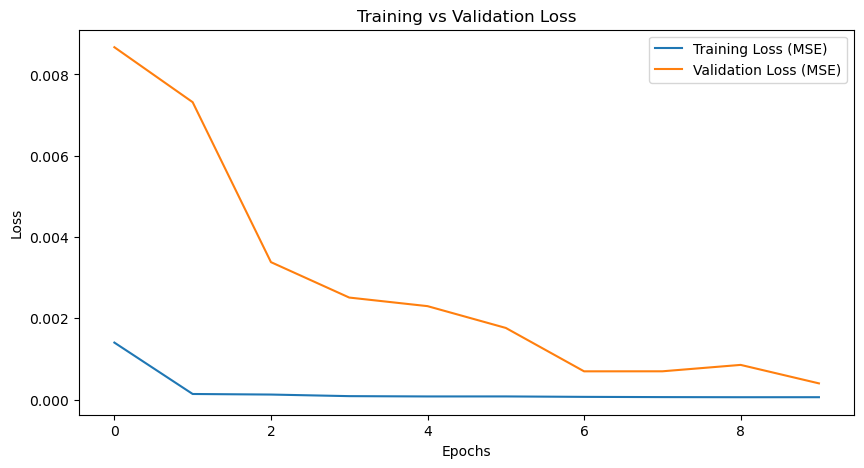

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [25]:
sp500_min_train = data_train[:, 0].min()
sp500_max_train = data_train[:, 0].max()
sp500_delta = sp500_max_train - sp500_min_train

In [27]:
n_rec = random.randint(0, X_test.shape[0] - 1)
predicted_price = y_pred[n_rec][0] * sp500_delta + sp500_min_train
actual_price = y_test[n_rec] * sp500_delta + sp500_min_train

NameError: name 'y_pred' is not defined

In [ ]:

print(f"\nSample Prediction (Record {n_rec}):")
print(f" Predicted Price: {predicted_price:.2f}")
print(f" Actual Price:    {actual_price:.2f}")
print(f" Absolute Error:  {abs(predicted_price - actual_price):.2f}")
print(f" % Error:         {abs(predicted_price - actual_price) / actual_price * 100:.2f}%")